# Generic Backtest Engine

Stage 6 separates **strategy intent** from execution and financial simulation.
EMA is one producer of intent; the shared engine validates that intent,
executes at the next candle's OPEN, pairs fills into trades, and delegates
independent GROSS and cost-aware NET accounting.

```text
Market candles → strategy-specific signal generation
                          ↓
             canonical Decision-010 intent
                          ↓
              run_backtest_pipeline(...)
                          ↓
     execution | trades | gross_results | net_results
                          ↓
             optional downstream analytics
```

This notebook introduces no new trading strategy or financial logic.
It demonstrates existing EMA20/50 research and a tiny contract example.
Historical research only: no orders are sent and no real money is traded.

## Setup

Select the parent workspace's `.venv/` Python kernel. The same project-root
lookup used by the earlier notebooks makes reusable `src/` functions available.

In [1]:
from pathlib import Path
import hashlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "trading_lab").is_dir()
)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import load_ohlcv_csv
from trading_lab.strategies.ema_trend import generate_ema_signals
from trading_lab.backtest.pipeline import run_backtest_pipeline
from trading_lab.analytics.equity import (
    calculate_gross_mark_to_market_equity,
    calculate_net_mark_to_market_equity,
)

%matplotlib inline
print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/romankondratenko/trading-lab/Trading Lab
Python: /Users/romankondratenko/trading-lab/.venv/bin/python


/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Load the frozen local candles

The hourly observation window is **2025-10-01 00:00 UTC through
2026-10-01 00:00 UTC, exclusive**. The existing loader restores numeric/UTC
types and validates this complete window. It reads the original CSV without
changing it. If the local snapshot is absent, execution stops clearly.

The SHA-256 below is the existing frozen reference used by Stage 6.5 and
notebook 03. There is no downloader or network call in this notebook.

In [2]:
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"
START = pd.Timestamp("2025-10-01", tz="UTC")
END = pd.Timestamp("2026-10-01", tz="UTC")
HOUR = pd.Timedelta(hours=1)
FROZEN_SHA256 = "0be33013ae5decc74112c4a1cfdcb94b387830a37b9d1109b7f6c582d60f1975"

if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"Frozen local snapshot missing: {CSV_PATH}. This notebook does not download data."
    )
raw_hash_before = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
assert raw_hash_before == FROZEN_SHA256, "Frozen snapshot hash differs"

candles = load_ohlcv_csv(CSV_PATH, interval="60", start=START, end=END)
candles_before = candles.copy(deep=True)
assert len(candles) == 8760
assert candles.timestamp.iloc[0] == START
assert candles.timestamp.iloc[-1] == pd.Timestamp("2026-09-30 23:00", tz="UTC")
assert candles.open.iloc[0] == 114_051.1

display(pd.Series({
    "rows": len(candles),
    "first_candle_UTC": candles.timestamp.iloc[0],
    "last_candle_UTC": candles.timestamp.iloc[-1],
    "window_end_exclusive_UTC": END,
    "columns": ", ".join(candles.columns),
    "first_raw_OPEN": candles.open.iloc[0],
}, name="Frozen BTCUSDT 1h snapshot").to_frame())

,Frozen BTCUSDT 1h snapshot
rows,8760
first_candle_UTC,2025-10-01 00:00:00+00:00
last_candle_UTC,2026-09-30 23:00:00+00:00
window_end_exclusive_UTC,2026-10-01 00:00:00+00:00
columns,"timestamp, open, high, low, close, volume"
first_raw_OPEN,114051.1


## 2. A strategy is a separate layer

`generate_ema_signals(...)` knows EMA20/EMA50, crossovers, and its 50-candle
initialization period. The generic engine receives the resulting intent.

Decision 010 requires four aligned fields:

| Field | Meaning |
| --- | --- |
| `timestamp` | Source candle OPEN time, matching the market data. |
| `signal_time` | Availability after that candle completes: timestamp + one hour. |
| `signal` | `LONG_ENTRY`, `LONG_EXIT`, or `HOLD`. |
| `desired_position` | Integer 0 (flat) or 1 (long) after processing the signal. |

Additional EMA values and crossover flags are diagnostics. They do not
control generic execution. The small view below surrounds the first ENTRY.

In [3]:
strategy_output = generate_ema_signals(
    candles, fast_span=20, slow_span=50, warmup_candles=50,
)
strategy_before = strategy_output.copy(deep=True)
entry_signals = int(strategy_output.signal.eq("LONG_ENTRY").sum())
exit_signals = int(strategy_output.signal.eq("LONG_EXIT").sum())
assert (entry_signals, exit_signals) == (78, 77)

first_entry_row = strategy_output.index[strategy_output.signal.eq("LONG_ENTRY")][0]
assert strategy_output.loc[first_entry_row, "timestamp"] == pd.Timestamp("2025-10-13 02:00", tz="UTC")
print("ENTRY / EXIT signals:", entry_signals, "/", exit_signals)
display(strategy_output.iloc[first_entry_row - 1:first_entry_row + 3][[
    "timestamp", "ema_20", "ema_50", "signal", "desired_position", "signal_time",
]])

ENTRY / EXIT signals: 78 / 77


,timestamp,ema_20,ema_50,signal,desired_position,signal_time
289,2025-10-13 01:00:00+00:00,113735.867706,113754.288223,HOLD,0,2025-10-13 02:00:00+00:00
290,2025-10-13 02:00:00+00:00,113887.908877,113816.171037,LONG_ENTRY,1,2025-10-13 03:00:00+00:00
291,2025-10-13 03:00:00+00:00,113978.584222,113856.321193,HOLD,1,2025-10-13 04:00:00+00:00
292,2025-10-13 04:00:00+00:00,114048.652391,113889.967420,HOLD,1,2025-10-13 05:00:00+00:00


## 3. Run the generic backtest

The same `run_backtest_pipeline(...)` accepts any valid Decision-010 intent.
It owns call order only; existing helpers own validation, execution, pairing,
and financial calculations. It does not generate a strategy internally.

**Research assumptions:** 10,000 USDT starting capital, a 0.10% fee per side,
and 0.05% adverse slippage per side. These frozen Stage 5 model parameters
are not claims about current Bybit fees.

| Returned key | Contents |
| --- | --- |
| `execution` | One row per candle, including next-OPEN fill metadata and executed state. |
| `trades` | One row per actually executed entry, paired with an exit when present. |
| `gross_results` | Zero-cost trade accounting. |
| `net_results` | Independent cost-aware sizing and accounting. |

In [4]:
INITIAL_CAPITAL = 10_000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005
EXPECTED_KEYS = ["execution", "trades", "gross_results", "net_results"]

result = run_backtest_pipeline(
    candles, strategy_output, initial_capital=INITIAL_CAPITAL,
    fee_rate=FEE_RATE, slippage_rate=SLIPPAGE_RATE,
)
assert list(result) == EXPECTED_KEYS
execution = result["execution"]
trades = result["trades"]
gross_results = result["gross_results"]
net_results = result["net_results"]
display(result.keys())

dict_keys(['execution', 'trades', 'gross_results', 'net_results'])

## 4. Intent versus execution

Candle N must complete before its signal is known. A valid event fills at
candle N+1's OPEN, using the market OPEN and its timestamp. Execution
time/price are stored on the source signal row N; `executed_position`
changes on row N+1.

The first ENTRY is decided from the **02:00** candle and fills at **03:00**
for **115,332.3 USDT**. Desired state changes before executed state.
This temporary display joins only a few rows for teaching; the engine's
outputs remain separate. Adjacent CLOSE and OPEN prices can coincide,
so fill timing identifies the next-OPEN convention.

In [5]:
first_fill = execution.loc[first_entry_row]
assert first_fill.timestamp == pd.Timestamp("2025-10-13 02:00", tz="UTC")
assert first_fill.execution_time == pd.Timestamp("2025-10-13 03:00", tz="UTC")
assert first_fill.execution_price == 115_332.3
assert first_fill.execution_price == candles.loc[first_entry_row + 1, "open"]
assert strategy_output.loc[first_entry_row, "desired_position"] == 1
assert first_fill.executed_position == 0
assert execution.loc[first_entry_row + 1, "executed_position"] == 1

execution_sample = execution.iloc[first_entry_row - 1:first_entry_row + 3][[
    "timestamp", "signal", "executed_position", "execution_time", "execution_price",
]].copy()
execution_sample.insert(2, "desired_position", strategy_output.loc[execution_sample.index, "desired_position"])
display(execution_sample)

,timestamp,signal,desired_position,executed_position,execution_time,execution_price
289,2025-10-13 01:00:00+00:00,HOLD,0,0,NaT,NaN
290,2025-10-13 02:00:00+00:00,LONG_ENTRY,1,0,2025-10-13 03:00:00+00:00,115332.3
291,2025-10-13 03:00:00+00:00,HOLD,1,1,NaT,NaN
292,2025-10-13 04:00:00+00:00,HOLD,1,1,NaT,NaN


## 5. The trade ledger records actual fills

Each executed entry creates one trade. It becomes CLOSED only when an exit
really fills. Ending the dataset does not create a closing order.

This snapshot has **78 trades: 77 CLOSED and one final OPEN**. The final
trade keeps missing `exit_time` and `exit_price`; no terminal liquidation
is forced. The preview shows the first three and last two trades.

In [6]:
closed_count = int(trades.status.eq("CLOSED").sum())
open_count = int(trades.status.eq("OPEN").sum())
assert (len(trades), closed_count, open_count) == (78, 77, 1)
assert trades.status.iloc[-1] == "OPEN"
assert trades.iloc[-1][["exit_time", "exit_price"]].isna().all()
print("Total / CLOSED / OPEN:", len(trades), "/", closed_count, "/", open_count)
display(pd.concat([trades.head(3), trades.tail(2)]))

Total / CLOSED / OPEN: 78 / 77 / 1


,trade_id,entry_time,entry_price,exit_time,exit_price,status
0,1,2025-10-13 03:00:00+00:00,115332.3,2025-10-14 06:00:00+00:00,112482.0,CLOSED
1,2,2025-10-19 16:00:00+00:00,108490.4,2025-10-21 10:00:00+00:00,107751.4,CLOSED
2,3,2025-10-21 15:00:00+00:00,112199.9,2025-10-22 04:00:00+00:00,108217.7,CLOSED
76,77,2026-09-29 14:00:00+00:00,84206.0,2026-09-29 16:00:00+00:00,83072.2,CLOSED
77,78,2026-09-30 13:00:00+00:00,85293.8,NaT,NaN,OPEN


## 6. GROSS and NET accounting are independent

GROSS allocates capital without fees or slippage. NET uses effective prices,
self-financing sizing that includes the entry fee, and its own net-capital
compounding. The separate cost-aware calculation can therefore use a
different quantity for each trade.

OPEN rows contain known entry-side accounting. Exit and realized-result
fields stay missing. `capital_before` means capital before entering the
position, rather than cash left after allocation. The summary below stops
at the last CLOSED trade; it does not value the final OPEN holding.

In [7]:
gross_closed = gross_results.loc[gross_results.status.eq("CLOSED")]
net_closed = net_results.loc[net_results.status.eq("CLOSED")]
accounting_summary = pd.DataFrame({
    "closed_trades": [len(gross_closed), len(net_closed)],
    "last_closed_realized_capital": [gross_closed.capital_after.iloc[-1], net_closed.net_capital_after.iloc[-1]],
    "final_trade_status": [gross_results.status.iloc[-1], net_results.status.iloc[-1]],
}, index=["GROSS", "NET"])
# Same scalar tolerance as the authoritative Stage 6.5 regression.
np.testing.assert_allclose(
    accounting_summary.last_closed_realized_capital.to_numpy(),
    [9641.111388344, 7652.530163437], rtol=1e-10,
)
assert gross_results.iloc[-1][["trade_return", "gross_pnl", "capital_after"]].isna().all()
assert net_results.iloc[-1][["net_pnl", "net_trade_return", "net_capital_after"]].isna().all()

print("GROSS — first two CLOSED trades")
display(gross_closed.head(2)[["trade_id", "capital_before", "quantity", "gross_pnl", "capital_after"]])
print("NET — first two CLOSED trades")
display(net_closed.head(2)[["trade_id", "capital_before", "quantity", "total_fees", "net_pnl", "net_capital_after"]])
print("Realized accounting summary")
display(accounting_summary)

GROSS — first two CLOSED trades


,trade_id,capital_before,quantity,gross_pnl,capital_after
0,1,10000.000000,0.086706,-247.138052,9752.861948
1,2,9752.861948,0.089896,-66.433205,9686.428743


NET — first two CLOSED trades


,trade_id,capital_before,quantity,total_fees,net_pnl,net_capital_after
0,1,10000.000000,0.086576,19.723391,-276.352802,9723.647198
1,2,9723.647198,0.089493,19.352056,-95.163035,9628.484163


Realized accounting summary


,closed_trades,last_closed_realized_capital,final_trade_status
GROSS,77,9641.111388,OPEN
NET,77,7652.530163,OPEN


## 7. Optional analytics compose downstream

`run_backtest_pipeline(...)` stops at trade accounting. Research can then
call the existing equity helpers on those outputs; equity is not added to
the engine's return dictionary.

Each path contains an initial capital observation and one mark after each
candle closes: **8,761 observations**. The final OPEN trade is **marked**
using raw CLOSE prices, without selling it or charging hypothetical exit
costs. Its marked value differs from last CLOSED realized capital.

In [8]:
gross_equity = calculate_gross_mark_to_market_equity(
    candles, gross_results, candle_interval=HOUR, initial_capital=INITIAL_CAPITAL,
)
net_equity = calculate_net_mark_to_market_equity(
    candles, net_results, candle_interval=HOUR, initial_capital=INITIAL_CAPITAL,
)
equity_summary = pd.DataFrame({
    "observations": [len(gross_equity), len(net_equity)],
    "final_marked_equity": [gross_equity.equity.iloc[-1], net_equity.equity.iloc[-1]],
    "final_active_trade_id": [gross_equity.active_trade_id.iloc[-1], net_equity.active_trade_id.iloc[-1]],
    "final_position": [gross_equity.position.iloc[-1], net_equity.position.iloc[-1]],
}, index=["GROSS", "NET"])
assert equity_summary.observations.tolist() == [8761, 8761]
assert equity_summary.final_active_trade_id.tolist() == [78, 78]
assert equity_summary.final_position.tolist() == [1, 1]
np.testing.assert_allclose(
    equity_summary.final_marked_equity.to_numpy(),
    [9451.485313939314, 7490.776562851941], rtol=1e-12, atol=1e-9,
)
display(equity_summary)

,observations,final_marked_equity,final_active_trade_id,final_position
GROSS,8761,9451.485314,78,1
NET,8761,7490.776563,78,1


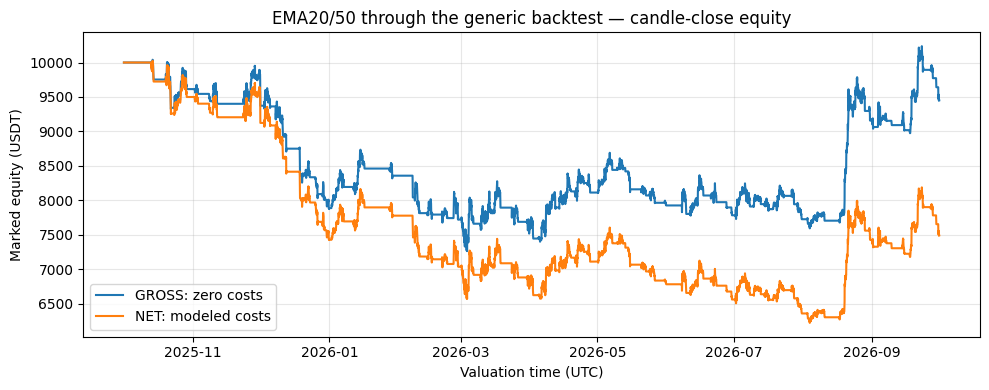

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gross_equity.valuation_time, gross_equity.equity, label="GROSS: zero costs")
ax.plot(net_equity.valuation_time, net_equity.equity, label="NET: modeled costs")
ax.set_title("EMA20/50 through the generic backtest — candle-close equity")
ax.set_xlabel("Valuation time (UTC)")
ax.set_ylabel("Marked equity (USDT)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8. The same engine accepts non-EMA intent

**This is a contract demonstration, not a proposed trading strategy.**

Five synthetic hourly candles need only `timestamp` and `open`. We manually
supply canonical HOLD → ENTRY → HOLD → EXIT → HOLD intent, with aligned
availability times and desired states. There are no EMA columns or calls
in this example. The same engine fills at the third and fifth candle OPENs
(100 and 110), then returns its four usual outputs.

In [10]:
synthetic_candles = pd.DataFrame({
    "timestamp": pd.date_range("2025-01-01", periods=5, freq="h", tz="UTC"),
    "open": [90.0, 95.0, 100.0, 105.0, 110.0],
})
synthetic_intent = synthetic_candles[["timestamp"]].copy()
synthetic_intent["signal_time"] = synthetic_intent.timestamp + HOUR
synthetic_intent["signal"] = ["HOLD", "LONG_ENTRY", "HOLD", "LONG_EXIT", "HOLD"]
synthetic_intent["desired_position"] = [0, 1, 1, 0, 0]
synthetic_result = run_backtest_pipeline(
    synthetic_candles, synthetic_intent, initial_capital=1_000.0,
    fee_rate=FEE_RATE, slippage_rate=SLIPPAGE_RATE,
)
assert list(synthetic_result) == EXPECTED_KEYS
assert synthetic_result["trades"].status.tolist() == ["CLOSED"]
assert synthetic_result["trades"].entry_price.iloc[0] == 100.0
assert synthetic_result["trades"].exit_price.iloc[0] == 110.0
assert synthetic_result["gross_results"].capital_after.iloc[0] == 1_100.0
assert synthetic_result["net_results"].net_capital_after.iloc[0] < 1_100.0

print("Canonical non-EMA intent")
display(synthetic_intent)
print("Shared execution and ledger")
display(synthetic_result["execution"])
display(synthetic_result["trades"])
print("Independent GROSS / NET accounting")
display(synthetic_result["gross_results"][["trade_id", "quantity", "gross_pnl", "capital_after"]])
display(synthetic_result["net_results"][["trade_id", "quantity", "total_fees", "net_pnl", "net_capital_after"]])

Canonical non-EMA intent


,timestamp,signal_time,signal,desired_position
0,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+00:00,HOLD,0
1,2025-01-01 01:00:00+00:00,2025-01-01 02:00:00+00:00,LONG_ENTRY,1
2,2025-01-01 02:00:00+00:00,2025-01-01 03:00:00+00:00,HOLD,1
3,2025-01-01 03:00:00+00:00,2025-01-01 04:00:00+00:00,LONG_EXIT,0
4,2025-01-01 04:00:00+00:00,2025-01-01 05:00:00+00:00,HOLD,0


Shared execution and ledger


,timestamp,open,signal,execution_time,execution_price,executed_position
0,2025-01-01 00:00:00+00:00,90.0,HOLD,NaT,NaN,0
1,2025-01-01 01:00:00+00:00,95.0,LONG_ENTRY,2025-01-01 02:00:00+00:00,100.0,0
2,2025-01-01 02:00:00+00:00,100.0,HOLD,NaT,NaN,1
3,2025-01-01 03:00:00+00:00,105.0,LONG_EXIT,2025-01-01 04:00:00+00:00,110.0,1
4,2025-01-01 04:00:00+00:00,110.0,HOLD,NaT,NaN,0


,trade_id,entry_time,entry_price,exit_time,exit_price,status
0,1,2025-01-01 02:00:00+00:00,100.0,2025-01-01 04:00:00+00:00,110.0,CLOSED


Independent GROSS / NET accounting


,trade_id,quantity,gross_pnl,capital_after
0,1,10.0,100.0,1100.0


,trade_id,quantity,total_fees,net_pnl,net_capital_after
0,1,9.985017,2.096804,96.704944,1096.704944


## 9. How a future strategy plugs in

A future producer may research breakouts, RSI, mean reversion, or momentum.
Its indicator rules stay inside that producer. Its final output must provide
aligned `timestamp`, `signal_time`, `signal`, and integer `desired_position`.
Optional diagnostics can accompany them. The generic engine stays the same.

Conceptual interface:

```python
def generate_my_strategy(candles, **parameters):
    # Use only information available from each completed candle.
    # Build the four aligned canonical intent fields here.
    ...
    return strategy_output

strategy_output = generate_my_strategy(candles)
result = run_backtest_pipeline(
    candles,
    strategy_output,
    initial_capital=10_000.0,
    fee_rate=0.001,
    slippage_rate=0.0005,
)
```

Stage 6.5 remains the authoritative exact EMA compatibility test. A future
strategy also needs its own causality checks; validating its output contract
alone does not prove that its indicator calculations avoid lookahead.

## 10. Lightweight notebook audit

The assertions above check the frozen window, signal/trade counts, first fill,
realized capital, and final marks. The final checks verify that research left
the source candles, strategy intent, and raw CSV bytes unchanged.

These sanity checks complement `tests/test_ema_generic_regression.py`;
this notebook does not repeat its full analytics regression suite.

In [11]:
pd.testing.assert_frame_equal(candles, candles_before, check_exact=True)
pd.testing.assert_frame_equal(strategy_output, strategy_before, check_exact=True)
assert hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before
display(pd.Series({
    "frozen_snapshot_identity": "passed",
    "EMA_signal_and_trade_counts": "passed",
    "first_next_OPEN_fill": "passed",
    "realized_and_marked_references": "passed",
    "synthetic_non_EMA_contract": "passed",
    "inputs_and_raw_bytes_preserved": "passed",
}, name="Notebook audit").to_frame())

,Notebook audit
frozen_snapshot_identity,passed
EMA_signal_and_trade_counts,passed
first_next_OPEN_fill,passed
realized_and_marked_references,passed
synthetic_non_EMA_contract,passed
inputs_and_raw_bytes_preserved,passed


## Takeaways

1. Strategy logic is isolated in the signal producer.
2. Canonical intent feeds shared validation and next-OPEN execution.
3. Trade pairing and independent GROSS/NET accounting are shared.
4. Strategy diagnostics do not control fills or accounting.
5. A new strategy can reuse the engine by satisfying the same contract.
6. Stage 6.5 proved that EMA behavior and frozen Stage 5 results remain unchanged.
7. Centralized risk management belongs to future Stage 7; it is not implemented.

The final holding remains OPEN. The equity chart marks it without liquidation.
This is one historical research sample with modeled costs, not evidence of
future profitability. Stage 6.7 — Final Stage 6 Audit + Docs awaits approval.